In [80]:
import matplotlib.pyplot as plt 
import numpy as np 

def science_plot(fontsize=9, scistyle=True, show_latex=True):
    # Default settings (applied to both 2D and 3D)
    if scistyle:
        import scienceplots
        plt.style.use(['science','grid','notebook'])
    if show_latex:
        plt.rcParams.update({
            # Latex Use
            'text.usetex'     : True,        # Use LaTeX for text rendering
            'font.family'     : 'serif',     # Set font family to serif
        })

    plt.rcParams.update({
        # Fontsizes
        'font.size'       : fontsize,    # General font size
        'axes.titlesize'  : fontsize,    # Font size of the axes title
        'axes.labelsize'  : fontsize,    # Font size of the axes labels
        'xtick.labelsize' : fontsize,    # Font size of the x-axis tick labels
        'ytick.labelsize' : fontsize,    # Font size of the y-axis tick labels
        'legend.fontsize' : fontsize,    # Font size of the legend
        'figure.titlesize': fontsize,    # Font size of the figure title

        # Legend
        'legend.fancybox' : False,       # Disable the fancy box for legend
        'legend.edgecolor': 'k',         # Set legend border color to black
    })
science_plot(fontsize=9)

PLANCK CONSTANT DETERMINATION RESULTS
Experimental Planck's constant: 7.169e-34 J·s
Theoretical Planck's constant: 6.626e-34 J·s
Percent difference: 8.20%
R-squared value: 0.9984
Standard error: 1.28e-35
Intercept (work function): -1.00e-19 J
Chi-squared: 0.35
Final value = 7.2±2 e-34 J·s


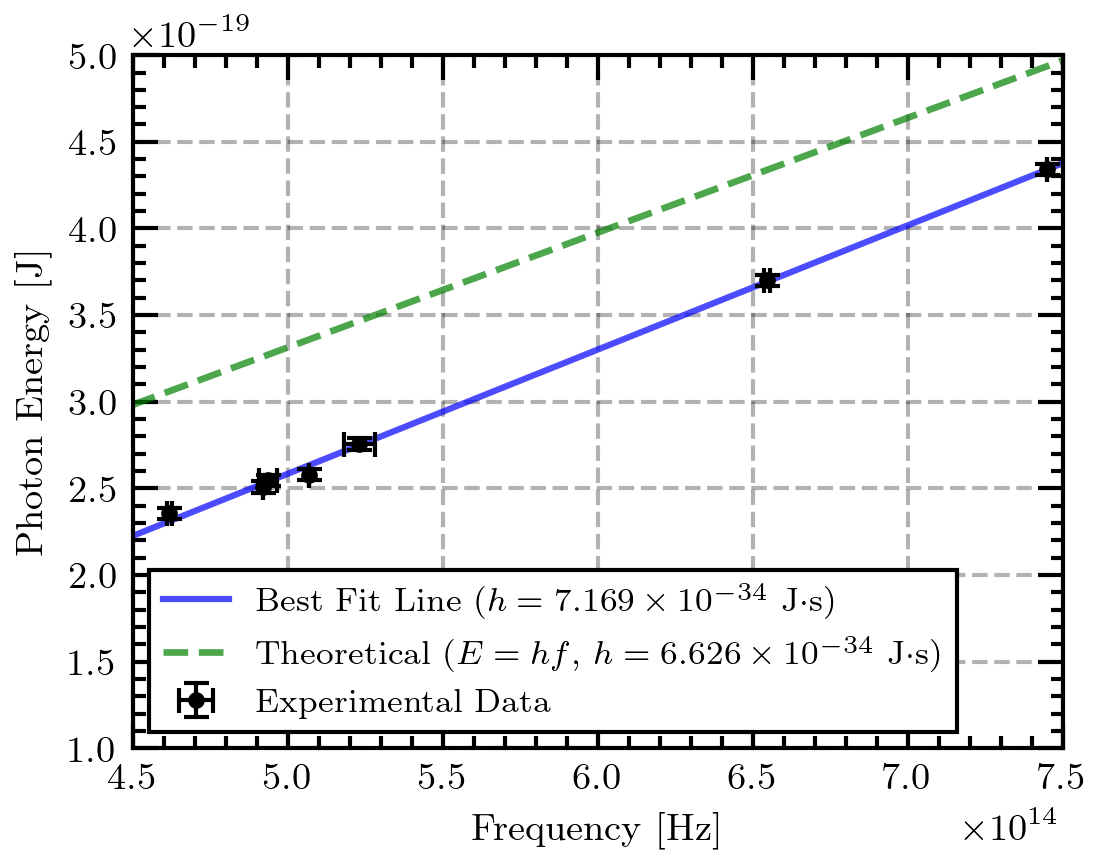

In [113]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Your data
wavelengths = np.array([
    (649.08),#+649.38)/2,
    #(609.4),#+609.8)/2,
    (609.4),#+609.167)/2,
    (607.3),#+609.033)/2,
    (591.5),#+590.52)/2,
    (573.1),#+571.617)/2,
    (458.0),#4+454.733)/2,
    (402.4),#+402.2)/2
    ])  # in nm
wavelengths_std = np.array([
    0.531,
    #0,
    0,
    1.718,
    0,
    2.778,
    0.358,
    0
])
voltages = np.array([
    1.47,
    #1.56,
    1.565,
    1.59,
    1.61,
    1.72,
    2.31,
    2.71
])  # stopping voltages
#assume voltage std is 0.01
voltage_std = 0.01

# Convert to proper units
e = 1.60217663e-19 # electron charge in coulombs
energy = voltages * e  # Convert eV to Joules
energy_std = voltage_std * e  # Error propagation for energy

frequencies = (1e9) * 299792458 / wavelengths  # Convert nm to frequency in Hz
# Error propagation for frequency: df = |dλ| * (c/λ²)
frequencies_std = wavelengths_std * (1e9 * 299792458 / (wavelengths**2))

# Perform linear regression
slope, intercept, r_value, p_value, std_err = stats.linregress(frequencies, energy)

# Create best fit line
f_fit = np.linspace(min(frequencies)*(0.95), max(frequencies)*(1.15), 100)
energy_fit = slope * f_fit + intercept

# Theoretical Planck's constant line for comparison
h_theoretical = 6.62607015e-34
f_range = np.linspace(0, max(frequencies)*1.1, 1000)
e_theoretical = h_theoretical * f_range

def sci_notation(num, decimals=3):
    """Return a LaTeX string like 6.626×10^{−34}."""
    exponent = int(np.floor(np.log10(abs(num))))
    mantissa = num / 10**exponent
    return rf"{mantissa:.{decimals}f}\times10^{{{exponent}}}"

# Plotting
plt.figure(figsize=(4, 3),dpi=300)
plt.errorbar(frequencies, energy, xerr=2*frequencies_std, yerr=2*energy_std, 
             fmt='.', color='k', label='Experimental Data', zorder=5, 
             capsize=3, capthick=1, elinewidth=1)
# plt.scatter(frequencies, energy, color='k', marker='.')
plt.plot(f_fit, energy_fit, 'b-', label=rf'Best Fit Line ($h = {sci_notation(slope)}$ J·s)', linewidth=1.5, alpha=0.7)
plt.plot(f_range, e_theoretical, 'g--', label=rf'Theoretical ($E=hf$, $h= {sci_notation(h_theoretical)}$ J·s)', lw=1.6, alpha=0.7)

plt.xlabel('Frequency [Hz]')
plt.ylabel('Photon Energy [J]')
#plt.title('Planck Constant Determination')
plt.legend(fontsize=8)
plt.grid(True, alpha=0.3)

# Calculate statistics
residuals = energy - (slope * frequencies + intercept)
chi_squared = np.sum((residuals / (energy * 0.05))**2)  # Assuming 5% error

print("="*50)
print("PLANCK CONSTANT DETERMINATION RESULTS")
print("="*50)
print(f"Experimental Planck's constant: {slope:.3e} J·s")
print(f"Theoretical Planck's constant: {h_theoretical:.3e} J·s")
print(f"Percent difference: {abs((slope - h_theoretical)/h_theoretical * 100):.2f}%")
print(f"R-squared value: {r_value**2:.4f}")
print(f"Standard error: {std_err:.2e}")
print(f"Intercept (work function): {intercept:.2e} J")
print(f"Chi-squared: {chi_squared:.2f}")
print("="*50)
print(f"Final value = 7.2±2 e-34 J·s")
plt.xlim(4.5e14,7.5e14)
plt.ylim(1e-19,5e-19)
plt.show()

=== LINEAR REGRESSION RESULTS ===
Slope (h): 7.1694e-34 J·s
Intercept: -1.0011e-19 J
R²: 0.99841
p-value: 3.451e-08
Standard Error: 1.281e-35
67% Confidence Interval: [7.0312e-34, 7.3076e-34]
95% Confidence Interval: [6.8400e-34, 7.4988e-34]
Percent difference: 8.20%

=== PAIRWISE SLOPE STATISTICS ===
Count: 21
Mean: 7.5545e-34
Median: 7.1388e-34
Standard Deviation: 3.9886e-34
IQR: 7.9864e-35
Min: 2.4301e-34
Max: 2.3546e-33
Percent difference: 7.74%

[5.06106959e-34 6.05067754e-34 4.98883386e-34 6.54122436e-34
 6.98421256e-34 7.01671173e-34 2.35459455e-33 4.84290970e-34
 7.96980364e-34 7.33986404e-34 7.24911940e-34 2.43008032e-34
 7.07034532e-34 7.16854701e-34 7.13882946e-34 1.08305300e-33
 7.59148417e-34 7.39952032e-34 7.19055254e-34 7.14792100e-34
 7.08595418e-34]


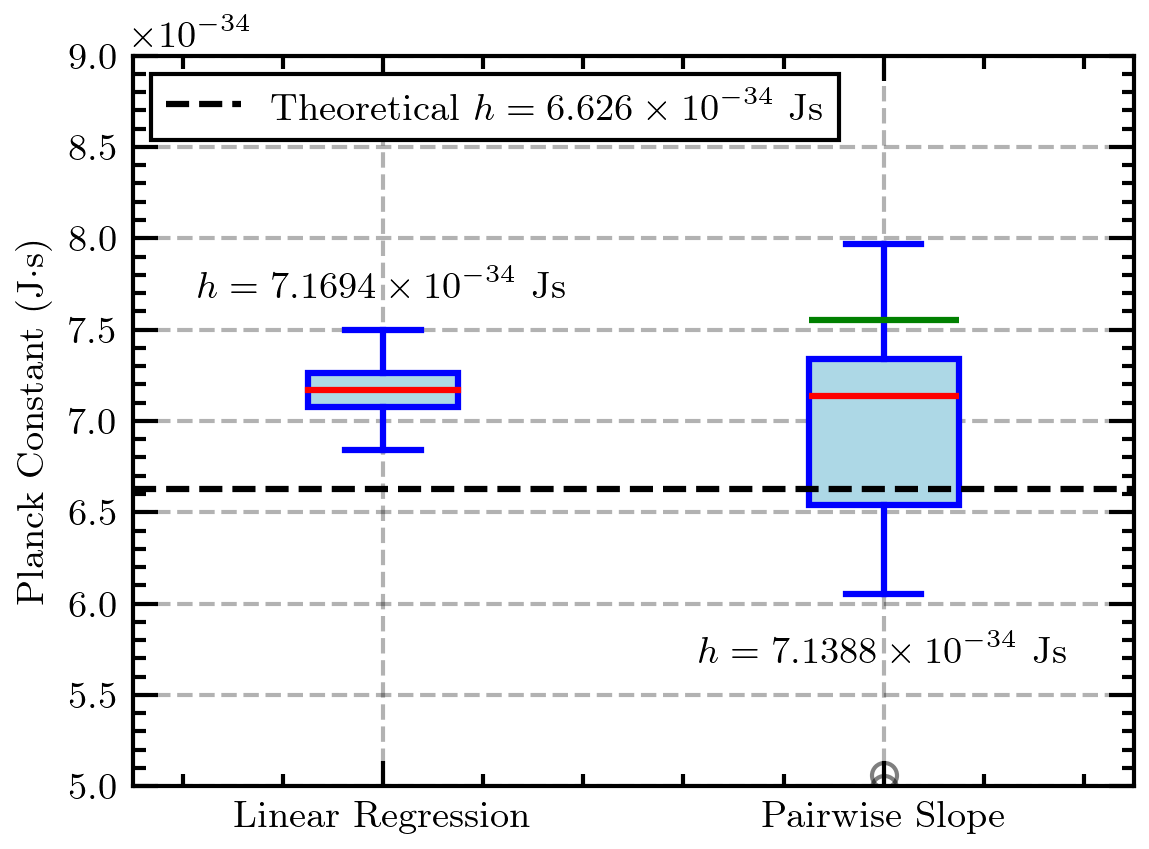

In [112]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import itertools

# Your data
wavelengths = np.array([
    649.08,
    609.4,
    607.3,
    591.5,
    573.1,
    458.0,
    402.4
])  # in nm
wavelengths_std = np.array([
    0.531,
    0,
    1.718,
    0,
    2.778,
    0.358,
    0
])
voltages = np.array([
    1.47,
    1.565,
    1.59,
    1.61,
    1.72,
    2.31,
    2.71
])  # stopping voltages

voltage_std = 0.01  # assumed

# Convert to proper units
e = 1.60217663e-19  # electron charge (C)
energy = voltages * e
energy_std = voltage_std * e

frequencies = (1e9) * 299792458 / wavelengths
frequencies_std = wavelengths_std * (1e9 * 299792458 / (wavelengths**2))

# Linear regression
slope, intercept, r_value, p_value, std_err = stats.linregress(frequencies, energy)
n = len(frequencies)

# Compute confidence intervals for regression slope
t_crit_50 = stats.t.ppf(1 - 0.25, n - 2)  # 50% CI
t_crit_67 = stats.t.ppf(1 - 0.165, n - 2) # 67% CI (~1σ)
t_crit_95 = stats.t.ppf(1 - 0.025, n - 2) # 95% CI (~2σ)
t_crit_99 = stats.t.ppf(1 - 0.005, n - 2) # 99% CI (~3σ)
slope_CI_50 = (slope - t_crit_50 * std_err, slope + t_crit_50 * std_err)
slope_CI_99 = (slope - t_crit_99 * std_err, slope + t_crit_99 * std_err)
slope_CI_95 = (slope - t_crit_95 * std_err, slope + t_crit_95 * std_err)
slope_CI_67 = (slope - t_crit_67 * std_err, slope + t_crit_67 * std_err)

# Pairwise Planck constant values
h_values = []
for i, j in itertools.combinations(range(len(frequencies)), 2):
    delta_energy = energy[j] - energy[i]
    delta_freq = frequencies[j] - frequencies[i]
    h_pair = delta_energy / delta_freq
    h_values.append(h_pair)

h_values = np.array(h_values)
h_theoretical = 6.62607015e-34

# ----------------------------
# PRINT SUMMARY STATISTICS
# ----------------------------
print("=== LINEAR REGRESSION RESULTS ===")
print(f"Slope (h): {slope:.4e} J·s")
print(f"Intercept: {intercept:.4e} J")
print(f"R²: {r_value**2:.5f}")
print(f"p-value: {p_value:.3e}")
print(f"Standard Error: {std_err:.3e}")
print(f"67% Confidence Interval: [{slope_CI_67[0]:.4e}, {slope_CI_67[1]:.4e}]")
print(f"95% Confidence Interval: [{slope_CI_95[0]:.4e}, {slope_CI_95[1]:.4e}]")
print(f"Percent difference: {abs((slope - h_theoretical)/h_theoretical * 100):.2f}%")
print()

print("=== PAIRWISE SLOPE STATISTICS ===")
print(f"Count: {len(h_values)}")
print(f"Mean: {np.mean(h_values):.4e}")
print(f"Median: {np.median(h_values):.4e}")
print(f"Standard Deviation: {np.std(h_values, ddof=1):.4e}")
print(f"IQR: {np.percentile(h_values, 75) - np.percentile(h_values, 25):.4e}")
print(f"Min: {np.min(h_values):.4e}")
print(f"Max: {np.max(h_values):.4e}")
print(f"Percent difference: {abs((np.median(h_values)- h_theoretical)/h_theoretical * 100):.2f}%")
print()
print(h_values)
# ----------------------------
# BUILD CUSTOM BOXPLOT-LIKE DATA
# ----------------------------
# For linear regression: fake "box" data representing confidence intervals
linreg_box = dict(
    med=slope,
    q1=slope_CI_50[0],
    q3=slope_CI_50[1],
    whisker_low=slope_CI_95[0],
    whisker_high=slope_CI_95[1]
)

# ----------------------------
# PLOT
# ----------------------------
fig, ax = plt.subplots(figsize=(4, 3),dpi=300)

# --- Pairwise boxplot ---
pairwise_box = ax.boxplot(
    [h_values],
    positions=[2],
    widths=0.3,
    showmeans=True,
    meanline=True,
    patch_artist=True,
    boxprops=dict(facecolor='lightblue', color='blue', linewidth=1.5),
    medianprops=dict(color='red', linewidth=1.5),
    meanprops=dict(color='green', linestyle='-', linewidth=1.5),
    whiskerprops=dict(color='blue', linewidth=1.5),
    capprops=dict(color='blue', linewidth=1.5),
    flierprops=dict(marker='o', color='black', alpha=0.5)
)

# --- Custom linear regression "box" ---
boxwidth = 0.3
ax.plot([1, 1], [linreg_box['whisker_low'], linreg_box['q1']], color='blue', linewidth=1.5)  # whiskers
ax.plot([1, 1], [linreg_box['q3'], linreg_box['whisker_high']], color='blue', linewidth=1.5)  # whiskers
ax.add_patch(plt.Rectangle(
    (0.85, linreg_box['q1']),
    0.3,
    linreg_box['q3'] - linreg_box['q1'],
    fill=True, color='lightblue', ec='blue', lw=1.5
))
ax.plot([1-boxwidth/2,1+boxwidth/2], [linreg_box['med'], linreg_box['med']], color='red', lw=1.5)  # median line
ax.plot([1, 1], [linreg_box['med'], linreg_box['med']], color='green', lw=2)  # mean marker (same as median)
ax.plot([1-boxwidth/4,1+boxwidth/4], [linreg_box['whisker_high'], linreg_box['whisker_high']], color='b', lw=1.5)  # whisker high
ax.plot([1-boxwidth/4,1+boxwidth/4], [linreg_box['whisker_low'], linreg_box['whisker_low']], color='b', lw=1.5)  # whisker low
plt.plot()
# Horizontal line for theoretical h
ax.axhline(y=h_theoretical, color='k', linestyle='--', linewidth=1.5, label=f'Theoretical $h = {sci_notation(h_theoretical)}$ Js')

# Labels and formatting
ax.set_ylabel(r"Planck Constant (J$\cdot$s)")
#ax.set_title("Comparison of Planck Constant Estimates")
ax.set_xticks([1, 2])
ax.set_xticklabels(['Linear Regression', 'Pairwise Slope'])
ax.grid(alpha=0.3)
ax.set_ylim(5e-34, 9e-34)
ax.legend()
ax.set_xlim(0.5,2.5)
ax.text(1,7.75e-34, r'$h=7.1694\times 10^{-34}\text{ Js}$',ha='center',va='center')
ax.text(2,5.75e-34, r'$h=7.1388\times 10^{-34}\text{ Js}$',ha='center',va='center')
plt.tight_layout()
plt.show()


=== LINEAR REGRESSION RESULTS (Bootstrap, Outliers Removed) ===
Slope (h): 7.1694e-34 J·s
R²: 0.99841
Median (clean): 7.1694e-34
IQR (clean): 1.1940e-35
95% CI: [7.0268e-34, 7.3636e-34]

=== PAIRWISE SLOPE STATISTICS (Outliers Removed) ===
Count: 15
Median: 7.1479e-34
IQR: 2.5096e-35



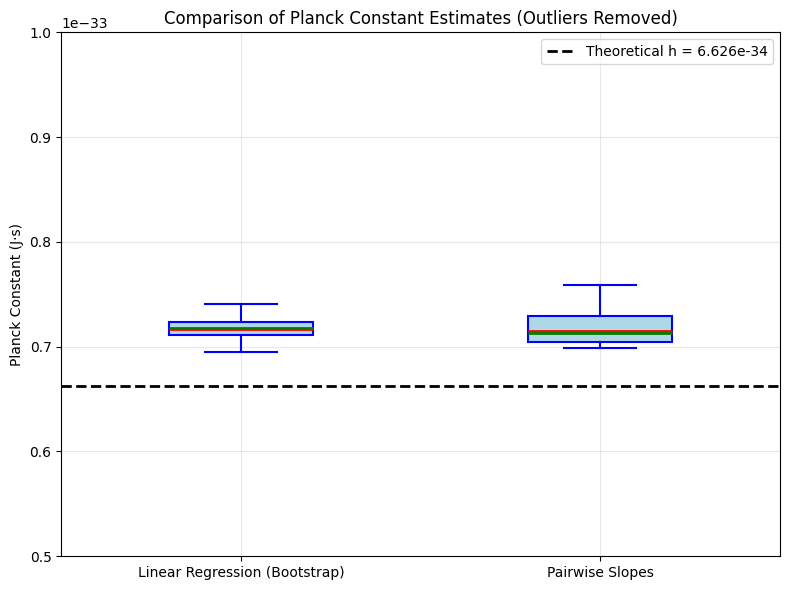

In [57]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import itertools

# Your data
wavelengths = np.array([649.08, 609.4, 607.3, 591.5, 573.1, 458.0, 402.4])  # nm
voltages = np.array([1.47, 1.565, 1.59, 1.61, 1.72, 2.31, 2.71])  # stopping voltages
voltage_std = 0.01

# Physical constants
e = 1.60217663e-19
energy = voltages * e
frequencies = (1e9) * 299792458 / wavelengths

# --- Linear regression ---
slope, intercept, r_value, p_value, std_err = stats.linregress(frequencies, energy)
n = len(frequencies)
h_theoretical = 6.62607015e-34

# --- Bootstrap resampling ---
rng = np.random.default_rng(123)
n_boot = 10000
slopes_boot = np.empty(n_boot)

for k in range(n_boot):
    idx = rng.integers(0, n, n)
    f_boot = frequencies[idx]
    e_boot = energy[idx]
    s, _, _, _, _ = stats.linregress(f_boot, e_boot)
    slopes_boot[k] = s

# --- Remove outliers (1.5 IQR rule) ---
def remove_outliers(data):
    q1, q3 = np.percentile(data, [25, 75])
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return data[(data >= lower) & (data <= upper)]

slopes_boot_clean = remove_outliers(slopes_boot)

# --- Pairwise h values ---
h_values = []
for i, j in itertools.combinations(range(len(frequencies)), 2):
    delta_energy = energy[j] - energy[i]
    delta_freq = frequencies[j] - frequencies[i]
    h_pair = delta_energy / delta_freq
    h_values.append(h_pair)

h_values = np.array(h_values)
h_values_clean = remove_outliers(h_values)

# --- Print summaries ---
print("=== LINEAR REGRESSION RESULTS (Bootstrap, Outliers Removed) ===")
print(f"Slope (h): {slope:.4e} J·s")
print(f"R²: {r_value**2:.5f}")
print(f"Median (clean): {np.median(slopes_boot_clean):.4e}")
print(f"IQR (clean): {np.percentile(slopes_boot_clean, 75) - np.percentile(slopes_boot_clean, 25):.4e}")
print(f"95% CI: [{np.percentile(slopes_boot_clean, 2.5):.4e}, {np.percentile(slopes_boot_clean, 97.5):.4e}]")
print()

print("=== PAIRWISE SLOPE STATISTICS (Outliers Removed) ===")
print(f"Count: {len(h_values_clean)}")
print(f"Median: {np.median(h_values_clean):.4e}")
print(f"IQR: {np.percentile(h_values_clean, 75) - np.percentile(h_values_clean, 25):.4e}")
print()

# --- Plot ---
fig, ax = plt.subplots(figsize=(8, 6))

data = [slopes_boot_clean, h_values_clean]
labels = ['Linear Regression (Bootstrap)', 'Pairwise Slopes']

ax.boxplot(
    data,
    widths=0.4,
    showmeans=True,
    meanline=True,
    patch_artist=True,
    boxprops=dict(facecolor='lightblue', color='blue', linewidth=1.5),
    medianprops=dict(color='red', linewidth=2),
    meanprops=dict(color='green', linestyle='-', linewidth=2),
    whiskerprops=dict(color='blue', linewidth=1.5),
    capprops=dict(color='blue', linewidth=1.5),
    flierprops=dict(marker='o', color='black', alpha=0)  # invisible (but none should remain)
)

# Theoretical Planck constant
ax.axhline(y=h_theoretical, color='k', linestyle='--', linewidth=2, label=f'Theoretical h = {h_theoretical:.3e}')

ax.set_ylabel("Planck Constant (J·s)")
ax.set_title("Comparison of Planck Constant Estimates (Outliers Removed)")
ax.set_xticklabels(labels)
ax.grid(alpha=0.3)
ax.set_ylim(5e-34, 10e-34)
ax.legend()

plt.tight_layout()
plt.show()


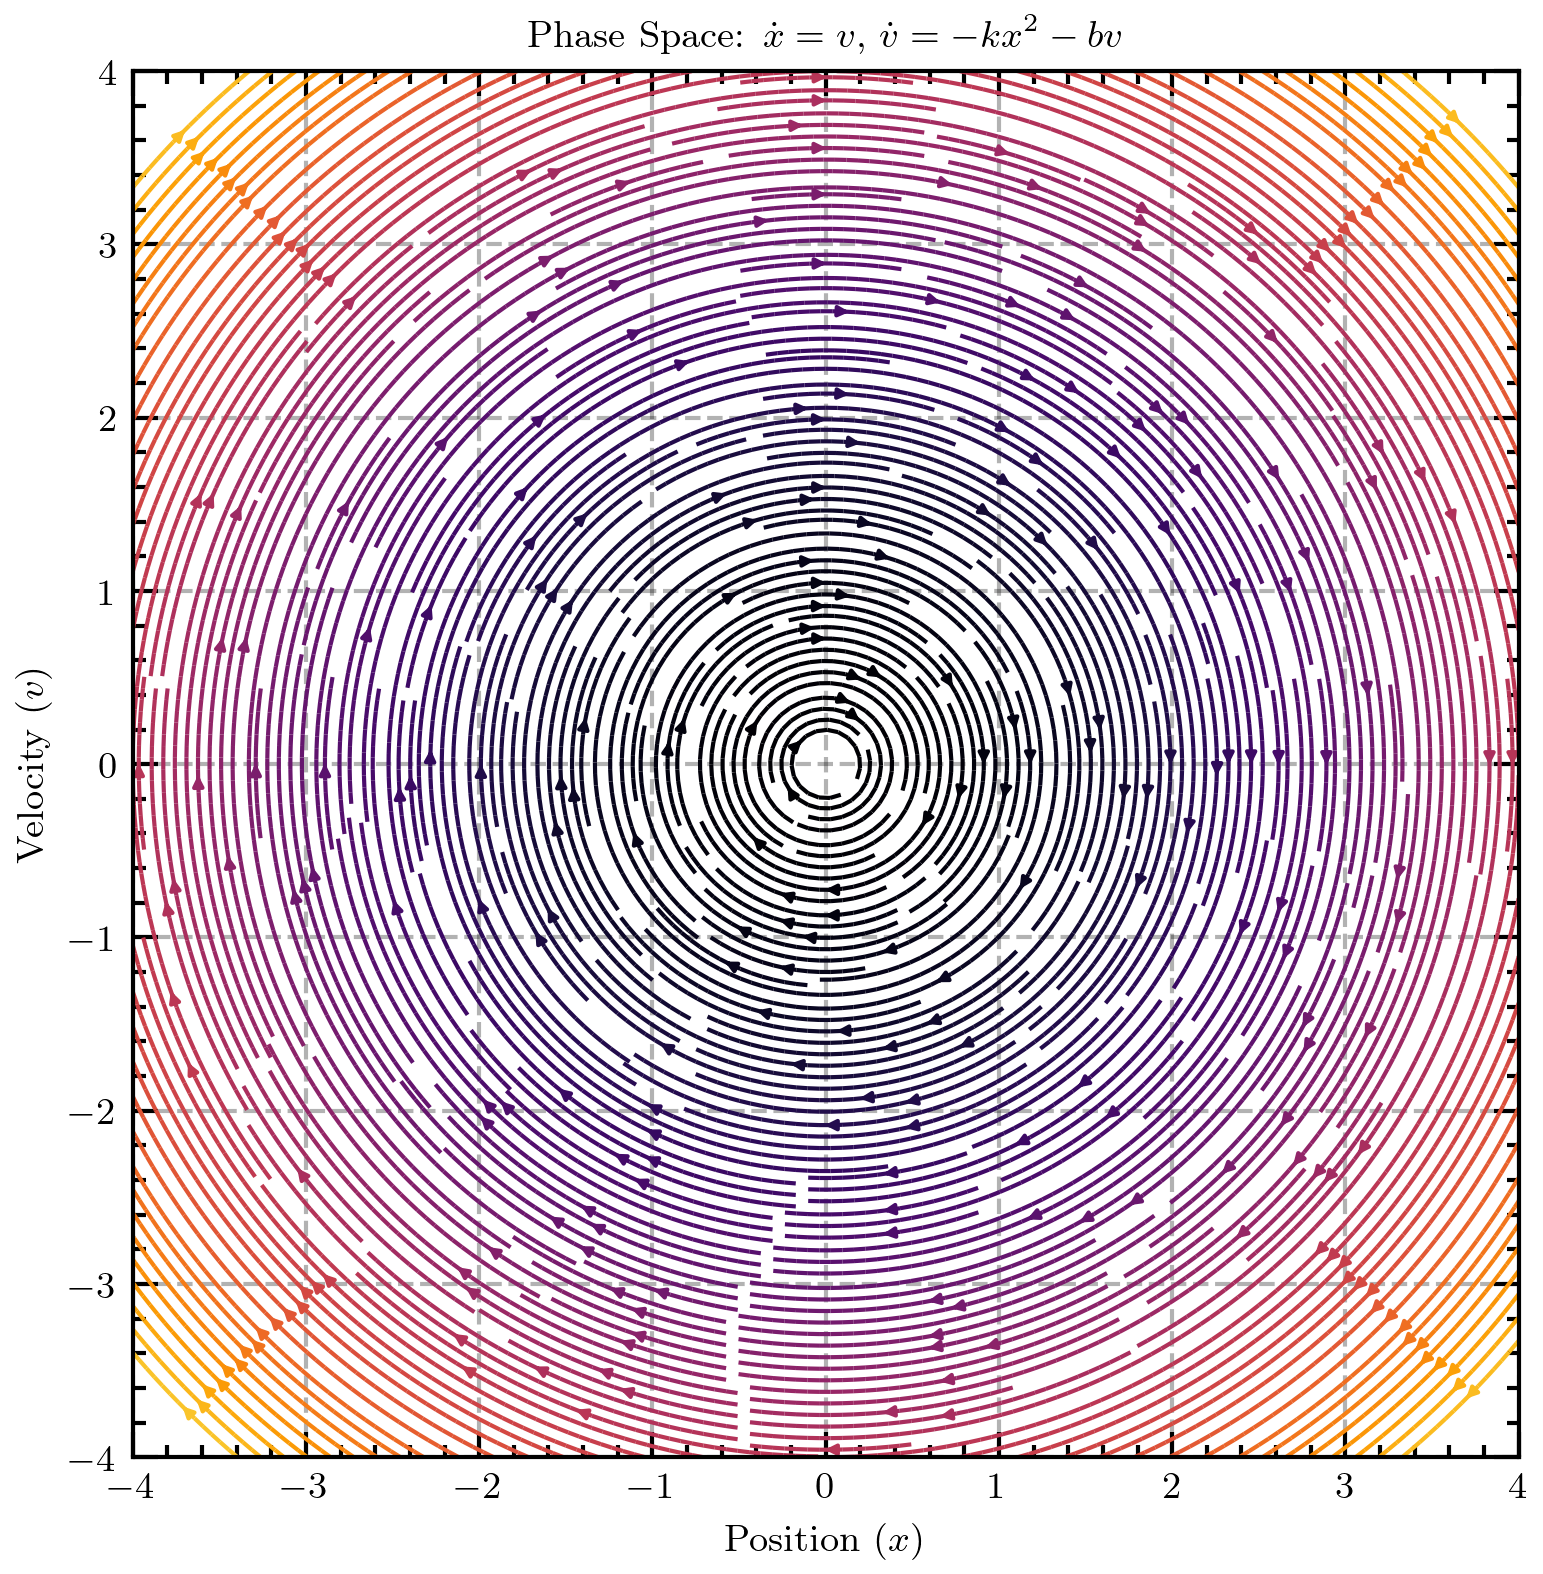

In [155]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-4, 4, 100)
v = np.linspace(-4, 4, 100)

# Create a meshgrid
X, V = np.meshgrid(x, v)

b = 0
k = 1
m = 1

def acc(x_val, v_val):
    # x_dot = velocity
    # v_dot = acceleration = -k*x**2 - b*v
    x_dot = v_val
    v_dot = (-k * x_val - b * v_val)/m
    return x_dot, v_dot

# Compute the vector field
X_dot, V_dot = acc(X, V)

# Calculate magnitude for coloring
mag = (0.5*k*X_dot**2 + 0.5*m*V_dot**2)

# Create the streamplot
plt.figure(figsize=(6, 6),dpi=300)
plt.streamplot(X, V, X_dot, V_dot, density=4, linewidth=1, color=mag, cmap='inferno',arrowsize=0.5)
#plt.colorbar(label='Velocity Magnitude')
plt.xlabel('Position ($x$)')
plt.ylabel('Velocity ($v$)')
plt.title(r'Phase Space: $\dot{x} = v$, $\dot{v} = -kx^2 - bv$')
plt.grid(True, alpha=0.3)
plt.gca().set_aspect('equal')
plt.show()

C:\Users\verci\AppData\Local\Temp\ipykernel_4348\1584471386.py:54: RuntimeWarning: overflow encountered in scalar power
  k4_v = -k * (r_i + dt * k3_r)**2
C:\Users\verci\AppData\Local\Temp\ipykernel_4348\1584471386.py:42: RuntimeWarning: overflow encountered in scalar power
  k1_v = - k * r_i**2


C:\Users\verci\AppData\Local\Temp\ipykernel_4348\1584471386.py:99: RuntimeWarning: overflow encountered in power
  energy = 0.5 * v**2 - (k/3) * r**3  # E = 1/2 v^2 - k/3 r^3


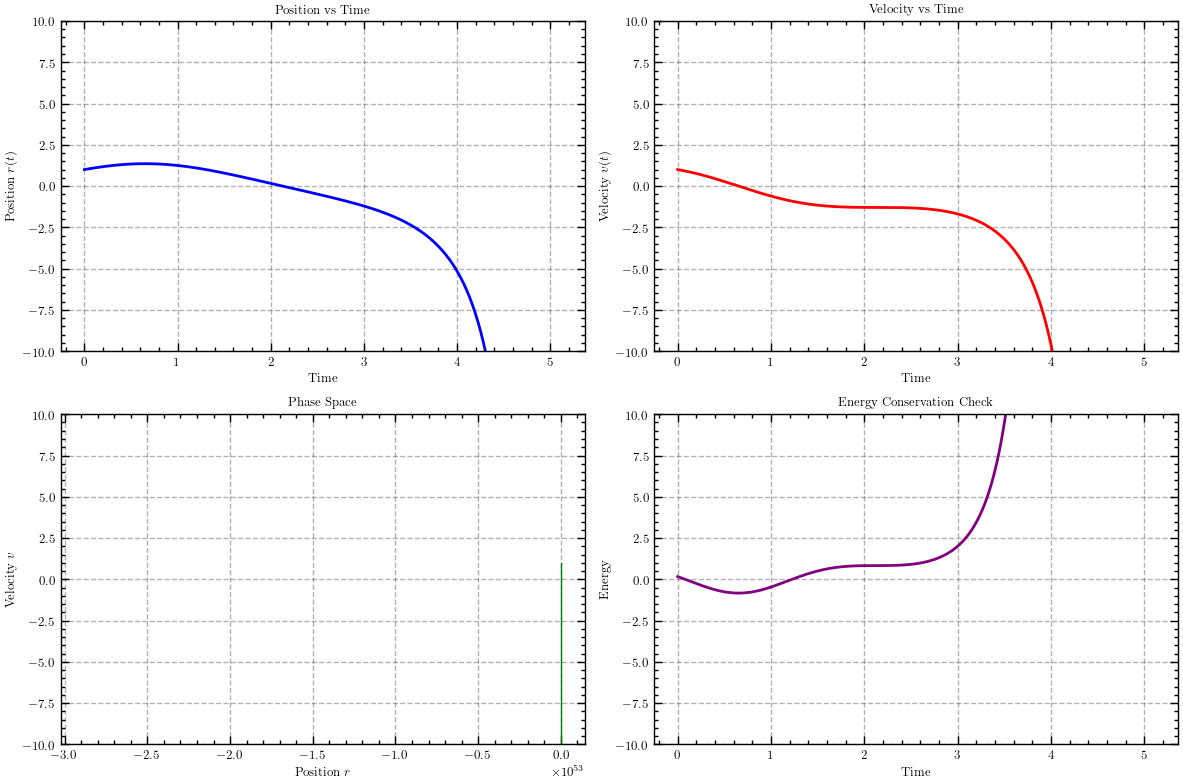

C:\Users\verci\AppData\Local\Temp\ipykernel_4348\1584471386.py:50: RuntimeWarning: overflow encountered in scalar power
  k3_v = -k * (r_i + 0.5 * dt * k2_r)**2


RuntimeError: latex was not able to process the following string:
b'r\\u2080=1, v\\u2080=0'

Here is the full command invocation and its output:

latex -interaction=nonstopmode --halt-on-error --output-directory=tmpq7md15qz ef93f7929e38c3b461136297901ed6b5.tex

This is pdfTeX, Version 3.141592653-2.6-1.40.25 (MiKTeX 24.1) (preloaded format=latex.fmt)
 restricted \write18 enabled.
entering extended mode
(ef93f7929e38c3b461136297901ed6b5.tex
LaTeX2e <2023-11-01> patch level 1
L3 programming layer <2024-01-22>
(C:\Users\verci\AppData\Local\Programs\MiKTeX\tex/latex/base\article.cls
Document Class: article 2023/05/17 v1.4n Standard LaTeX document class
(C:\Users\verci\AppData\Local\Programs\MiKTeX\tex/latex/base\size10.clo))
(C:\Users\verci\AppData\Local\Programs\MiKTeX\tex/latex/type1cm\type1cm.sty)
(C:\Users\verci\AppData\Local\Programs\MiKTeX\tex/latex/cm-super\type1ec.sty
(C:\Users\verci\AppData\Local\Programs\MiKTeX\tex/latex/base\t1cmr.fd))
(C:\Users\verci\AppData\Local\P

<Figure size 1000x600 with 1 Axes>

In [138]:
import numpy as np
import matplotlib.pyplot as plt

def rk4_second_order(k, r0, v0, t_span, dt):
    """
    RK4 solver for ddot_r = k * r^2
    
    Parameters:
    k: constant
    r0: initial position
    v0: initial velocity  
    t_span: tuple (t_start, t_end)
    dt: time step
    
    Returns:
    t: time array
    r: position array
    v: velocity array
    """
    t_start, t_end = t_span
    n_steps = int((t_end - t_start) / dt)
    
    t = np.linspace(t_start, t_end, n_steps)
    r = np.zeros(n_steps)
    v = np.zeros(n_steps)
    
    r[0] = r0
    v[0] = v0
    
    for i in range(n_steps - 1):
        # Convert to first-order system:
        # y = [r, v]
        # dy/dt = [v, k*r^2]
        
        # Current state
        r_i = r[i]
        v_i = v[i]
        
        # RK4 coefficients for the system
        # k1 = f(t, y)
        k1_r = v_i
        k1_v = - k * r_i**2
        
        # k2 = f(t + dt/2, y + dt/2 * k1)
        k2_r = v_i + 0.5 * dt * k1_v
        k2_v = -k * (r_i + 0.5 * dt * k1_r)**2
        
        # k3 = f(t + dt/2, y + dt/2 * k2)  
        k3_r = v_i + 0.5 * dt * k2_v
        k3_v = -k * (r_i + 0.5 * dt * k2_r)**2
        
        # k4 = f(t + dt, y + dt * k3)
        k4_r = v_i + dt * k3_v
        k4_v = -k * (r_i + dt * k3_r)**2
        
        # Update
        r[i + 1] = r_i + (dt / 6) * (k1_r + 2*k2_r + 2*k3_r + k4_r)
        v[i + 1] = v_i + (dt / 6) * (k1_v + 2*k2_v + 2*k3_v + k4_v)
    
    return t, r, v

# Example usage
k = 1.0
r0 = 1.0      # initial position
v0 = 1      # initial velocity
t_span = (0, 10)
dt = 0.01

t, r, v = rk4_second_order(k, r0, v0, t_span, dt)

# Plot results
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.plot(t, r, 'b-', linewidth=2)
plt.xlabel('Time')
plt.ylabel('Position $r(t)$')
plt.title('Position vs Time')
plt.ylim(-10,10)
plt.grid(True, alpha=0.3)

plt.subplot(2, 2, 2)
plt.plot(t, v, 'r-', linewidth=2)
plt.xlabel('Time')
plt.ylabel('Velocity $v(t)$')
plt.title('Velocity vs Time')
plt.grid(True, alpha=0.3)
plt.ylim(-10,10)

plt.subplot(2, 2, 3)
plt.plot(r, v, 'g-', linewidth=1)
plt.xlabel('Position $r$')
plt.ylabel('Velocity $v$')
plt.title('Phase Space')
plt.grid(True, alpha=0.3)
plt.ylim(-10,10)

plt.subplot(2, 2, 4)
energy = 0.5 * v**2 - (k/3) * r**3  # E = 1/2 v^2 - k/3 r^3
plt.plot(t, energy, 'purple', linewidth=2)
plt.xlabel('Time')
plt.ylabel('Energy')
plt.title('Energy Conservation Check')
plt.grid(True, alpha=0.3)
plt.ylim(-10,10)

plt.tight_layout()
plt.show()

# Test with different initial conditions
plt.figure(figsize=(10, 6))
colors = ['red', 'blue', 'green', 'orange', 'purple']

for i, (r0, v0) in enumerate([(1, 0), (2, 0), (0.5, 1), (1, -1), (0, 2)]):
    t, r, v = rk4_second_order(k, r0, v0, (0, 5), 0.01)
    plt.plot(r, v, color=colors[i], linewidth=2, label=f'r₀={r0}, v₀={v0}')

plt.xlabel('Position $r$')
plt.ylabel('Velocity $v$')
plt.title('Phase Space for Different Initial Conditions')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()